# Analysis Case study Shangai Co-Processing

### Define parameters

In [62]:
C_max = 6       # Cement Kilns
F_max = 2       # Fuel Types
G_max = 8       # Waste Generation Sites
H_max = 5       # Subsidy Levels
I_max = 6       # Incineration Plants
K_max = 3       # Pre- & Co-Processing Facilitiy Capacities
L_max = 3       # Landfill Sites
S_max = 8       # Transfer Stations
W_max = 2       # Waste Types

Q_gw = [[426, 498], [411, 189], [141, 136], [875, 566], [959, 464], [577, 343], [651, 679], [589, 404]]
T_tot = 7908
Q_i = [986.8222353702523, 980.1216878627922, 1037.3651575246379, 1026.1906303189587, 856.1833978984705, 872.9839858073137]
Q_k = [200, 350, 500]
Q_k_max = 500
Q_l = [1155.0518048239073, 1223.1871230614513, 1109.5220480255414]
Q_s = [1020, 1280, 1180, 1300, 1130, 1080, 1190, 1170]

TD_gs = [[9, 19, 35, 13, 14, 44, 16, 33], [47, 7, 42, 23, 12, 15, 37, 36], [14, 25, 6, 45, 37, 13, 46, 17], [24, 50, 50, 5, 13, 46, 47, 35], [13, 24, 12, 45, 4, 28, 36, 19], [44, 17, 46, 29, 45, 5, 16, 47], [46, 50, 22, 33, 16, 45, 3, 46], [13, 49, 23, 41, 44, 37, 30, 6]]
TD_sc = [[207.59162776098822, 198.59101855115205, 292.62314066513716, 319.2945113699449, 156.91618494836746, 163.11278455702538], [175.35569820060994, 175.63877080080943, 217.87871129866704, 233.0891704632911, 181.48727741201202, 92.66764590184403], [208.15109380771145, 200.31101386603487, 229.61816065605825, 317.1215518072743, 249.85169706132706, 222.18586493532135], [237.56485707460382, 247.336976926857, 126.00566719842867, 297.2440759312057, 267.1280668645153, 289.8638240140759], [270.9866658915946, 204.02118024812427, 205.05986657179312, 143.70756684605612, 240.2675940894855, 129.39751620732113], [131.38118859122056, 170.46279273540944, 159.76393270561712, 195.45606596237315, 125.39783775135624, 83.02401232358268], [157.0038008500462, 143.06665701054547, 199.38806030652808, 111.6170010803193, 289.8133146035071, 237.00205010370445], [156.30975707582186, 179.4409576434048, 196.6947736846218, 199.4788970049049, 149.39319452135086, 283.0475959972458]]
TD_si = [[33, 31, 56, 21, 46, 28], [18, 38, 4, 7, 32, 26], [10, 48, 21, 9, 59, 31], [26, 2, 42, 4, 48, 35], [36, 50, 56, 52, 20, 21], [44, 22, 38, 31, 37, 51], [29, 4, 53, 5, 60, 17], [30, 44, 42, 4, 3, 46]]
TD_si_avg = 30.625
TD_sl = [[117.21846978397632, 114.35822502034456, 145.01455940561746], [124.68062464820615, 95.78658819199829, 101.66607122120105], [115.46233617024853, 70.07636721493161, 105.58101346338128], [87.4994128133575, 82.95497931098596, 76.28787545970611], [121.11468813568175, 84.12531863176275, 93.38063438037261], [101.9436963571348, 128.48533306915206, 79.04247503347776], [104.95935168874202, 109.7240343410324, 129.51053380855043], [124.49328355528036, 127.87182996528304, 95.39625390224984]]

alpha_c = [11036, 9912, 7237, 7228, 9288, 10868]
beta_f = [24.0, 27.0]
beta_w = [8.0, 16.0]
budget_cem = 350000000.0
budget_municipality = 1800000.0
c_inc = 120.0
c_invest_k = [70000000.0, 110000000.0, 150000000.0]
c_land = 55.0
c_penalty = 160.0
c_preproc_w = [150.0, 110.0]
c_truck = 0.45
cement_names = ['Anhui Conch Cement (cluster)', 'Suzhou Dahua Marine', 'Jiangsu Pengfei (Haian)', 'Zhejiang Producer A', 'Jiangsu Producer A', 'Anhui Producer A']
epsilon_inc = [0.54, 0.42]
epsilon_kiln_f = [2.54, 2.22]
epsilon_kiln_w = [0.3, 0.15]
epsilon_land = [1.7, 1.0]
epsilon_truck = 0.0002
fixcost_invest = [10170.20057941499, 15981.743767652128, 21793.286955889263]
kappa_coproc = 0.4
kappa_land = 0.35
phi_max = [220.0, 175.0]
price_f = [420.0, 520.0]
subsidy_wh = [[0.0, 55.0, 110.0, 165.0, 220.0], [0.0, 43.75, 87.5, 131.25, 175.0]]
tau = 0.001
weight_env = 1.0
weight_mon = 0.004

## Variable Values

In [18]:
import numpy as np

# Best solution found
Obj_Municipality = 12859.1

# First stage (upper level) variable values
q_gsw = np.zeros((8,8,2), dtype=int)
q_gsw[0,0,1] = 181
q_gsw[0,1,1] = 275
q_gsw[0,4,0] = 426
q_gsw[0,4,1] = 39
q_gsw[0,5,1] = 3
q_gsw[1,1,0] = 411
q_gsw[1,1,1] = 165
q_gsw[1,5,1] = 24
q_gsw[2,2,0] = 141
q_gsw[2,5,1] = 136
q_gsw[3,3,0] = 734
q_gsw[3,3,1] = 566
q_gsw[3,4,0] = 141
q_gsw[4,2,0] = 835
q_gsw[4,2,1] = 64
q_gsw[4,4,0] = 124
q_gsw[4,4,1] = 400
q_gsw[5,1,0] = 429
q_gsw[5,5,0] = 148
q_gsw[5,5,1] = 343
q_gsw[6,2,0] = 10
q_gsw[6,2,1] = 130
q_gsw[6,6,0] = 641
q_gsw[6,6,1] = 549
q_gsw[7,7,0] = 589
q_gsw[7,7,1] = 404

q_slw = np.zeros((8,3,2), dtype=int)
q_slw[2,1,1] = 194
q_slw[3,1,1] = 1
q_slw[3,2,1] = 517
q_slw[4,1,1] = 439

q_siw = np.zeros((8,6,2), dtype=int)
q_siw[0,5,1] = 181
q_siw[1,2,0] = 691
q_siw[1,2,1] = 346
q_siw[1,3,0] = 149
q_siw[2,0,0] = 986
q_siw[3,1,0] = 734
q_siw[3,1,1] = 48
q_siw[4,5,0] = 691
q_siw[5,1,0] = 148
q_siw[6,1,0] = 50
q_siw[6,3,0] = 551
q_siw[6,3,1] = 189
q_siw[7,3,0] = 137
q_siw[7,4,0] = 452
q_siw[7,4,1] = 404

z_wh = np.zeros((2,5), dtype=int)
z_wh[0,4] = 1
z_wh[1,4] = 1

T_land = 1151
T_inc = 5757
T_kiln = 1000

# Second stage (lower level) variable values
cost_coal = 698840
cost_preproc = 111600
cost_tiebreak = 119.804
cost_invest = 50851
revenue_subsidy = 176800

x_ck = np.zeros((6,3), dtype=int)
x_ck[0,0] = 1
x_ck[1,0] = 1
x_ck[3,0] = 1
x_ck[4,0] = 1
x_ck[5,0] = 1

q_cw = np.zeros((6,2), dtype=int)
q_cw[0,1] = 200
q_cw[1,0] = 1
q_cw[1,1] = 199
q_cw[3,0] = 39
q_cw[3,1] = 161
q_cw[4,1] = 200
q_cw[5,1] = 200


q_cf = np.zeros((6,2), dtype=int)
q_cf[0,0] = 322
q_cf[0,1] = 4
q_cf[1,0] = 280
q_cf[2,0] = 302
q_cf[3,0] = 181
q_cf[4,0] = 254
q_cf[5,0] = 315
q_cf[5,1] = 4

q_scw = np.zeros((8,6,2), dtype=int)
q_scw[1,5,1] = 94
q_scw[5,0,1] = 200
q_scw[5,4,1] = 200
q_scw[5,5,1] = 106
q_scw[6,1,0] = 1
q_scw[6,1,1] = 199
q_scw[6,3,0] = 39
q_scw[6,3,1] = 161

y_cwh = np.zeros((6,2,5), dtype=int)
y_cwh[0,1,4] = 200
y_cwh[1,0,4] = 1
y_cwh[1,1,4] = 199
y_cwh[3,0,4] = 39
y_cwh[3,1,4] = 161
y_cwh[4,1,4] = 200
y_cwh[5,1,4] = 200

q_cwk = np.zeros((6,2,3), dtype=int)
q_cwk[0,1,0] = 200
q_cwk[1,0,0] = 1
q_cwk[1,1,0] = 199
q_cwk[3,0,0] = 39
q_cwk[3,1,0] = 161
q_cwk[4,1,0] = 200
q_cwk[5,1,0] = 200

## Calculate cost Leader

### Calculate using loops
Transport Emission

In [20]:
emission_transport = epsilon_truck * (
    sum(q_gsw[g,s,w] * TD_gs[g][s] 
        for g in range(G_max) 
        for s in range(S_max) 
        for w in range(W_max)) +
    sum(q_slw[s,l,w] * TD_sl[s][l] 
        for s in range(S_max) 
        for l in range(L_max) 
        for w in range(W_max)) +
    sum(q_siw[s,i,w] * TD_si[s][i] 
        for s in range(S_max) 
        for i in range(I_max) 
        for w in range(W_max)) +
    sum(q_scw[s,c,w] * TD_sc[s][c] 
        for s in range(S_max) 
        for c in range(C_max) 
        for w in range(W_max))
)

print(f"Emission from Transport = {emission_transport}")

Emission from Transport = 64.07889152375621


Treatment Emission

In [21]:
emission_treatment = (
    sum(q_slw[s,l,w] * epsilon_land[w]
        for s in range(S_max) 
        for l in range(L_max) 
        for w in range(W_max)) +
    sum(q_siw[s,i,w] * epsilon_inc[w]
        for s in range(S_max)
        for i in range(I_max)
        for w in range(W_max))
)

print(f"Emission from Treatment = {emission_treatment}")

Emission from Treatment = 4119.620000000001


Fuel Emission

In [22]:
emission_fuel = (
    sum(q_cw[c,w] * epsilon_kiln_w[w]
        for c in range(C_max)
        for w in range(W_max)) +
    sum(q_cf[c,f] * epsilon_kiln_f[f]
        for c in range(C_max)
        for f in range(F_max))
)

print(f"Emission from Fuel = {emission_fuel}")

Emission from Fuel = 4374.92


### Calculate using Numpy Arrays

In [64]:
TD_gs = np.array(TD_gs)
TD_sl = np.array(TD_sl)
TD_si = np.array(TD_si)
TD_sc = np.array(TD_sc)

emission_transport = epsilon_truck * (
    np.sum(q_gsw*TD_gs[:, :, np.newaxis]) +
    np.sum(q_slw*TD_sl[:, :, np.newaxis]) +
    np.sum(q_siw*TD_si[:, :, np.newaxis]) +
    np.sum(q_scw*TD_sc[:, :, np.newaxis])
)
# np.sum(q_gsw[:,:,0]*TD_gs)    -> one specific waste type only, e.g. waste =1

emission_treatment = (
    np.sum(q_slw*epsilon_land) +
    np.sum(q_siw*epsilon_inc)
)

emission_fuel = (
    np.sum(q_cf*epsilon_kiln_f) +
    np.sum(q_cw*epsilon_kiln_w)
)

total_emission = emission_transport + emission_treatment + emission_fuel
print(f"Total Emission = Emission Transport + Emission Treatment + Emission Fuel\n "
      f"= {emission_transport} + {emission_treatment} + {emission_fuel} = {total_emission}")

Total Emission = Emission Transport + Emission Treatment + Emission Fuel
 = 64.07889152375621 + 4119.62 + 4374.92 = 8558.618891523756


In [65]:
cost_transport = c_truck * (
    np.sum(q_gsw*TD_gs[:,:,np.newaxis]) +
    np.sum(q_slw*TD_sl[:,:,np.newaxis]) +
    np.sum(q_siw*TD_si[:,:,np.newaxis]) +
    np.sum(q_scw*TD_sc[:,:,np.newaxis])
    # np.sum(r_sw*TD_si_avg)
)

cost_treatment = (
    np.sum(q_slw*c_land) +
    np.sum(q_siw*c_inc)
)

cost_subsidy = np.sum(subsidy_wh*y_cwh)

total_cost = cost_transport + cost_treatment + cost_subsidy
print(f"Total Cost = Cost Transport + Cost Treatment - Cost Subsidy\n "
      f"= {cost_transport} + {cost_treatment} + {cost_subsidy} = {total_cost}")

Total Cost = Cost Transport + Cost Treatment - Cost Subsidy
 = 144177.50592845146 + 754145.0 + 176800.0 = 1075122.5059284514


In [66]:
weighted_environmental_cost = weight_env * total_emission
weighted_monetary_cost = weight_mon * total_cost
overall_objective = weighted_environmental_cost + weighted_monetary_cost
print(f"Overall Objective = Weighted Environmental Cost + Weighted Monetary Cost\n "
      f"= {weighted_environmental_cost} + {weighted_monetary_cost} = {overall_objective}")

Overall Objective = Weighted Environmental Cost + Weighted Monetary Cost
 = 8558.618891523756 + 4300.490023713805 = 12859.10891523756


## Solutions Case study

In [ ]:
import matplotlib.pyplot as plt

plt.pie(
    [emission_transport, emission_treatment, emission_fuel],
    labels=['Transport', 'Treatment', 'Fuel'],
    autopct='%1.1f%%',
    startangle=140
)
plt.title('Emission Contribution by Source (Minicipality Objective)')
plt.show()

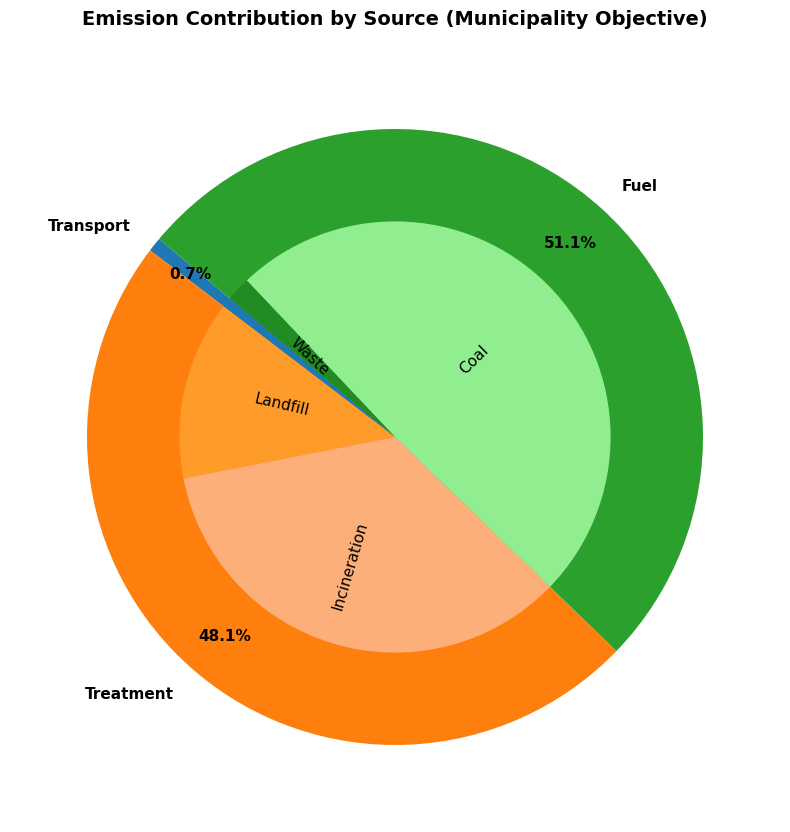

Emission Transport: 64.07889152375621
Emission Landfill: 1151.0
Emission Incineration: 2968.62
Emission Fuel - Coal: 4218.92
Emission Fuel - Waste: 156.0
Total Emission: 8558.618891523756


In [88]:
# Calculate separate emissions
emission_fuel_coal = np.sum(q_cf * epsilon_kiln_f)
emission_fuel_waste = np.sum(q_cw * epsilon_kiln_w)
emission_fuel = emission_fuel_coal + emission_fuel_waste

emission_landfill = np.sum(q_slw * epsilon_land)
emission_incineration = np.sum(q_siw * epsilon_inc)

# Create nested donut chart
fig, ax = plt.subplots(figsize=(12, 10))

# Outer ring - 3 main categories
outer_values = [emission_transport, emission_treatment, emission_fuel]
outer_labels = ['Transport', 'Treatment', 'Fuel']
outer_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

wedges_outer, texts_outer, autotexts_outer = ax.pie(
    outer_values,
    labels=outer_labels,
    autopct='%1.1f%%',
    pctdistance=0.85,
    startangle=140,
    colors=outer_colors,
    textprops={'size': 11, 'weight': 'bold'}
)

# Inner ring - 5 subcategories
inner_values = [emission_transport, emission_landfill, emission_incineration, 
                emission_fuel_coal, emission_fuel_waste]
inner_labels = ['', 'Landfill', 'Incineration', 'Coal', 'Waste']
inner_colors = ['#1f77b4', "#ff9b28", "#fdaf7a", '#90ee90', '#228b22']

def autopct_format(pct, allvals, index=[0]):
    if index[0] == 0:  # Skip first value (Transport)
        index[0] += 1
        return ''
    index[0] += 1
    return f'{pct:.1f}%'

wedges_inner, texts_inner = ax.pie(
    inner_values,
    radius=0.70,
    labels=inner_labels,
    rotatelabels=True,
    labeldistance=0.4,
    # autopct=lambda pct: autopct_format(pct, inner_values),
    # pctdistance=0.75,
    startangle=140,
    colors=inner_colors,
    textprops={'size': 11}
)

# White circle to create donut effect
# centre_circle = plt.Circle((0, 0), 0.70, fc='white')
# ax.add_artist(centre_circle)

plt.title('Emission Contribution by Source (Municipality Objective)', 
          fontsize=14, fontweight='bold', pad=20)
plt.show()

print(f"Emission Transport: {emission_transport}")
print(f"Emission Landfill: {emission_landfill}")
print(f"Emission Incineration: {emission_incineration}")
print(f"Emission Fuel - Coal: {emission_fuel_coal}")
print(f"Emission Fuel - Waste: {emission_fuel_waste}")
print(f"Total Emission: {emission_transport + emission_treatment + emission_fuel}")

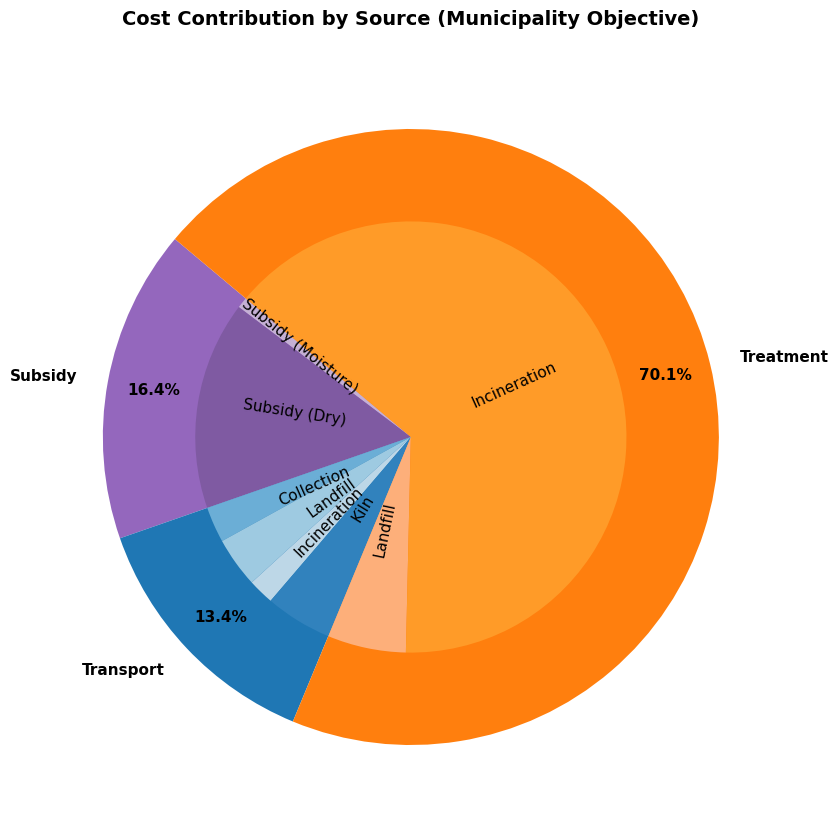

In [90]:
# --- Cost breakdown for nested donut chart ---

# Transport components
cost_transport_gs = c_truck * np.sum(q_gsw * TD_gs[:, :, np.newaxis])
cost_transport_sl = c_truck * np.sum(q_slw * TD_sl[:, :, np.newaxis])
cost_transport_si = c_truck * np.sum(q_siw * TD_si[:, :, np.newaxis])
cost_transport_sc = c_truck * np.sum(q_scw * TD_sc[:, :, np.newaxis])
cost_transport_total = cost_transport_gs + cost_transport_sl + cost_transport_si + cost_transport_sc

# Treatment components
cost_treatment_landfill = np.sum(q_slw * c_land)
cost_treatment_incineration = np.sum(q_siw * c_inc)
cost_treatment_total = cost_treatment_landfill + cost_treatment_incineration

# Subsidy components (per waste type w)
subsidy_wh = np.array(subsidy_wh)
cost_subsidy_w0 = sum(
    subsidy_wh[0,h]*y_cwh[c,0,h]
    for c in range(C_max)
    for h in range(H_max)
)
cost_subsidy_w1 = sum(
    subsidy_wh[1,h]*y_cwh[c,1,h]
    for c in range(C_max)
    for h in range(H_max)
)
cost_subsidy_total = cost_subsidy_w0 + cost_subsidy_w1

# Create nested donut chart for costs
fig, ax = plt.subplots(figsize=(12, 10))

# Outer ring - main categories
outer_values = [cost_subsidy_total, cost_transport_total, cost_treatment_total]
outer_labels = ['Subsidy', 'Transport', 'Treatment']
outer_colors = ['#9467bd', '#1f77b4', '#ff7f0e']

ax.pie(
    outer_values,
    labels=outer_labels,
    autopct='%1.1f%%',
    pctdistance=0.85,
    startangle=140,
    colors=outer_colors,
    textprops={'size': 11, 'weight': 'bold'}
)

# Inner ring - detailed components
inner_values = [
    cost_subsidy_w0, cost_subsidy_w1,
    cost_transport_gs, cost_transport_sl, cost_transport_si, cost_transport_sc,
    cost_treatment_landfill, cost_treatment_incineration
]
inner_labels = [
    'Subsidy (Moisture)', 'Subsidy (Dry)',
    'Collection', 'Landfill', 'Incineration', 'Kiln',
    'Landfill', 'Incineration'
]
inner_colors = [
    '#c5b0d5', '#7f5aa2',  # subsidy shades
    '#6baed6', '#9ecae1', '#bdd7e7', '#3182bd',  # transport shades
    "#fdaf7a", "#ff9b28",    # treatment shades
]

ax.pie(
    inner_values,
    radius=0.70,
    labels=inner_labels,
    rotatelabels=True,
    labeldistance=0.3,
    # autopct='%1.1f%%',
    # pctdistance=0.55,
    startangle=140,
    colors=inner_colors,
    textprops={'size': 11}
)

plt.title('Cost Contribution by Source (Municipality Objective)', fontsize=14, fontweight='bold', pad=20)
plt.show()

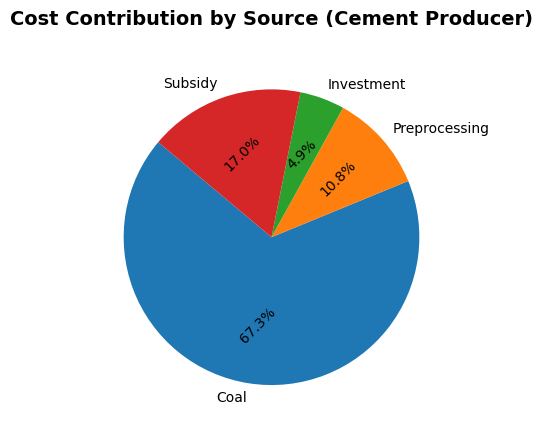

In [97]:

wedges, texts, autotexts = plt.pie(
    [cost_coal, cost_preproc, cost_invest, revenue_subsidy],
    labels=['Coal', 'Preprocessing', 'Investment', 'Subsidy'],
    autopct='%1.1f%%',
    startangle=140
)
# Rotate only the percentage values
for autotext in autotexts:
    autotext.set_rotation(45)

plt.title('Cost Contribution by Source (Cement Producer)', fontsize=14, fontweight='bold', pad=20)
plt.show()

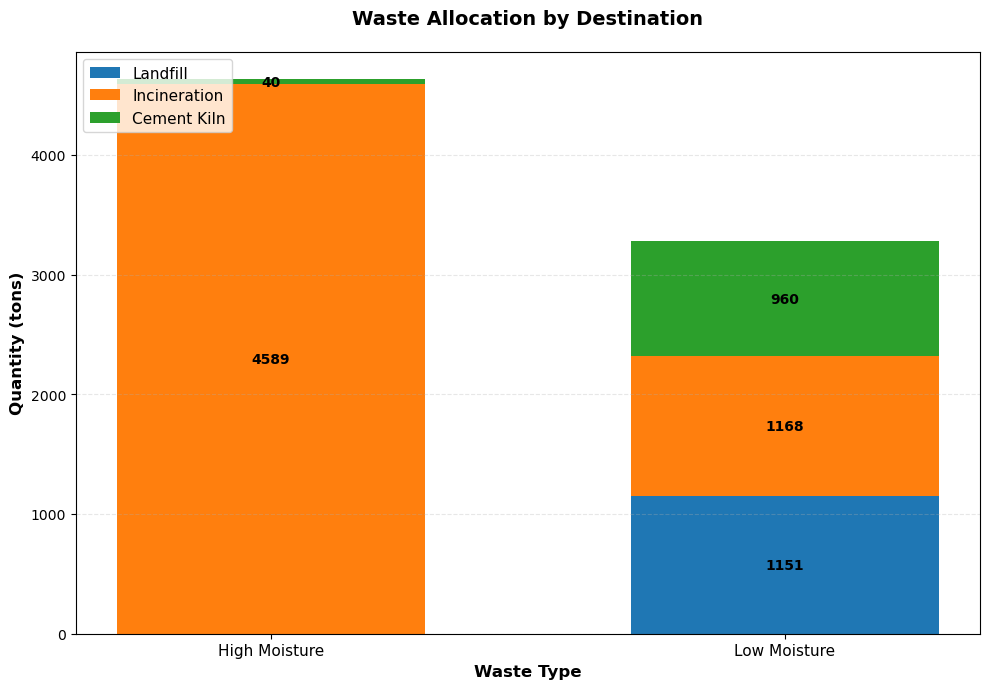

Landfill (Moisture): 0, (Dry): 1151, Total: 1151
Incineration (Moisture): 4589, (Dry): 1168, Total: 5757
Cement Kiln (Moisture): 40, (Dry): 960, Total: 1000
Total Waste Processed: 7908


In [98]:
import matplotlib.pyplot as plt

# Calculate total waste by destination
waste_to_landfill = np.sum(q_slw)
waste_to_incineration = np.sum(q_siw)
waste_to_kiln = np.sum(q_scw)

# Waste types labels
waste_types = ['High Moisture', 'Low Moisture']

# Allocation by waste type for each destination
landfill_by_type = [np.sum(q_slw[:, :, 0]), np.sum(q_slw[:, :, 1])]
incineration_by_type = [np.sum(q_siw[:, :, 0]), np.sum(q_siw[:, :, 1])]
kiln_by_type = [np.sum(q_scw[:, :, 0]), np.sum(q_scw[:, :, 1])]

# Create figure
fig, ax = plt.subplots(figsize=(10, 7))

# X positions
x = np.arange(len(waste_types))
width = 0.6

# Create stacked bars
bars1 = ax.bar(x, landfill_by_type, width, label='Landfill')
bars2 = ax.bar(x, incineration_by_type, width, bottom=landfill_by_type, 
               label='Incineration')

# Calculate bottom position for kiln (landfill + incineration)
kiln_bottom = [landfill_by_type[i] + incineration_by_type[i] for i in range(len(waste_types))]
bars3 = ax.bar(x, kiln_by_type, width, bottom=kiln_bottom, label='Cement Kiln')

# Add value labels on each segment
def add_value_labels(bars, values):
    for bar, value in zip(bars, values):
        if value > 0:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_y() + height/2.,
                   f'{int(value)}',
                   ha='center', va='center', fontweight='bold', fontsize=10, color='black')

add_value_labels(bars1, landfill_by_type)
add_value_labels(bars2, incineration_by_type)
add_value_labels(bars3, kiln_by_type)

# Labels and formatting
ax.set_xlabel('Waste Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Quantity (tons)', fontsize=12, fontweight='bold')
ax.set_title('Waste Allocation by Destination', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(waste_types, fontsize=11)
ax.legend(fontsize=11, loc='upper left')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Print summary
print(f"Landfill (Moisture): {landfill_by_type[0]}, (Dry): {landfill_by_type[1]}, Total: {waste_to_landfill}")
print(f"Incineration (Moisture): {incineration_by_type[0]}, (Dry): {incineration_by_type[1]}, Total: {waste_to_incineration}")
print(f"Cement Kiln (Moisture): {kiln_by_type[0]}, (Dry): {kiln_by_type[1]}, Total: {waste_to_kiln}")
print(f"Total Waste Processed: {waste_to_landfill + waste_to_incineration + waste_to_kiln}")